In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Fintech Fraud Analytics\creditcard.csv")

print("Data Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nTransaction Counts (0: Genuine, 1: Fraud):")
print(df['Class'].value_counts())

Data Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Transaction Counts (0: Genuine, 1: Fraud):
Class
0    284315
1       492
Name: count, dtype: int64


In [3]:
df_sorted = df.sort_values(by=['Amount', 'Time'])

df_sorted['Time_Diff'] = df_sorted['Time'].diff()
df_sorted['Amount_Diff'] = df_sorted['Amount'].diff()

duplicates = df_sorted[(df_sorted['Amount_Diff'] == 0) & (df_sorted['Time_Diff'] <= 30)]

print(f"Total potential duplicates found: {len(duplicates)}")

fraud_duplicates = duplicates[duplicates['Class'] == 1]
print(f"Duplicates that were actually FRAUD: {len(fraud_duplicates)}")

if len(fraud_duplicates) > 0:
    display(fraud_duplicates[['Time', 'Amount', 'Class']].head(10))

Total potential duplicates found: 51188
Duplicates that were actually FRAUD: 133


,Time,Amount,Class
541,406.0,0.0,1
42756,41233.0,0.0,1
93486,64443.0,0.0,1
93788,64585.0,0.0,1
141258,84204.0,0.0,1
143334,85285.0,0.0,1
154719,102671.0,0.0,1
183106,125658.0,0.0,1
191690,129371.0,0.0,1
226877,144839.0,0.0,1


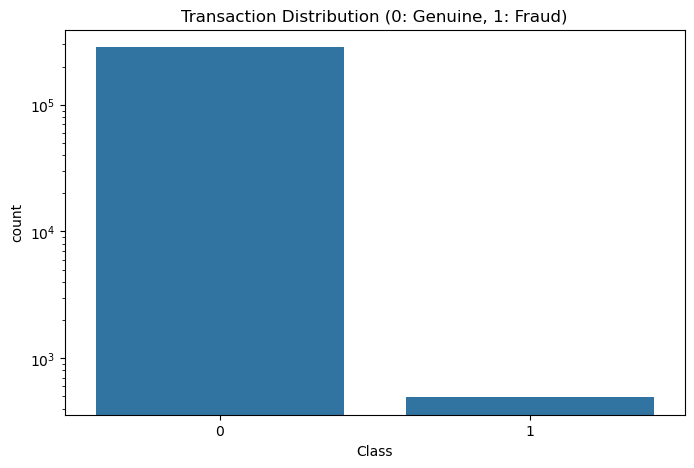

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(x='Class', data=df)
plt.title('Transaction Distribution (0: Genuine, 1: Fraud)')
plt.yscale('log') 
plt.show()

--- Genuine Transactions Amount Summary ---
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

--- Fraud Transactions Amount Summary ---
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


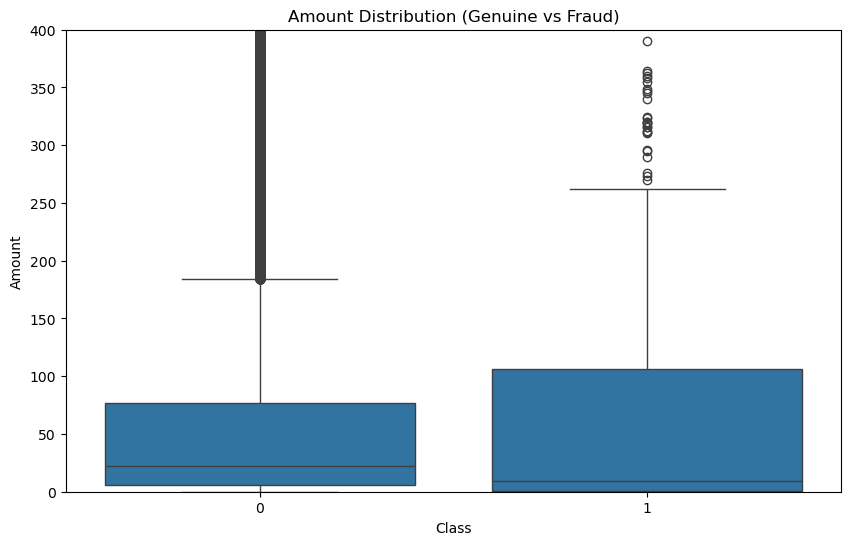

In [5]:
print("--- Genuine Transactions Amount Summary ---")
print(df[df['Class'] == 0]['Amount'].describe())

print("\n--- Fraud Transactions Amount Summary ---")
print(df[df['Class'] == 1]['Amount'].describe())

plt.figure(figsize=(10,6))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Amount Distribution (Genuine vs Fraud)')
plt.ylim(0, 400) 
plt.show()

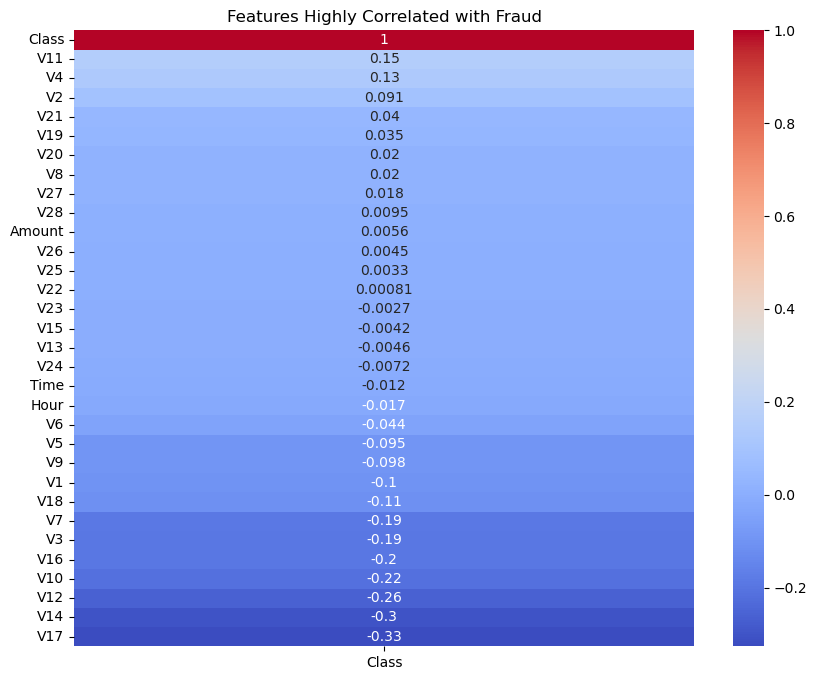

In [6]:
df['Hour'] = (df['Time'] // 3600) % 24

plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr[['Class']].sort_values(by='Class', ascending=False), annot=True, cmap='coolwarm')
plt.title('Features Highly Correlated with Fraud')
plt.show()

In [7]:
df['is_night'] = df['Hour'].apply(lambda x: 1 if x <= 6 else 0)

night_fraud_rate = df[df['is_night'] == 1]['Class'].mean() * 100
day_fraud_rate = df[df['is_night'] == 0]['Class'].mean() * 100

print(f"Fraud Rate during Night (12 AM - 6 AM): {night_fraud_rate:.4f}%")
print(f"Fraud Rate during Day: {day_fraud_rate:.4f}%")

Fraud Rate during Night (12 AM - 6 AM): 0.4744%
Fraud Rate during Day: 0.1398%


In [8]:
df.to_csv('fraud_analytics_final.csv', index=False)
print("File 'fraud_analytics_final.csv' successfully saved!")

File 'fraud_analytics_final.csv' successfully saved!


Project Conclusion & Key Insights

Based on the Exploratory Data Analysis (EDA) of the Fintech Fraud dataset, the following key observations were made:

1. Duplicate Transaction Pattern: By implementing a 30-second time-window logic, we successfully identified 133 actual fraud cases that were nearsimultaneous duplicate transactions. This indicates that fraudsters often attempt to "blast" transactions or test card limits in quick succession.
2. Midnight Anomaly: The fraud rate during the night (12 AM - 6 AM) is approximately 0.47%, which is 3.4 times higher than the daytime fraud rate of 0.14%. This suggests that security monitoring should be heightened during late-night hours.
3. Transaction Value Strategy: Fraudulent transactions have a significantly lower median value ($9.25) compared to genuine transactions ($22.00). This points toward a "Card Testing" strategy where small amounts are used to avoid triggering high-value security alerts.
4. Data Imbalance Challenge: The dataset is highly imbalanced, with fraud cases representing only 0.17% of total transactions. Any future predictive modeling must account for this skewness using techniques like SMOTE or undersampling.
